# DustSCAN Model Performance Visualization
This notebook parses the TensorBoard logs generated during training to visualize the loss and evaluation metrics over time.

In [ ]:
import os
import sys
import glob
import torch
import torch.nn.functional as F
import random
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Add root folder to sys.path to import from src
sys.path.append(os.path.abspath('..'))

from src.models import build_advanced_unet_model
from src.utils import IMAGENET_MEAN, IMAGENET_STD, GLOBAL_STATS

# Locate the latest TensorBoard log
log_dir = '../outputs/runs/dustscan_experiment'
event_files = glob.glob(os.path.join(log_dir, 'events.out.tfevents.*'))

def extract_scalars(event_file):
    ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
    ea.Reload()
    
    data = {}
    for tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        data[tag] = pd.DataFrame([(e.step, e.value) for e in events], columns=['step', tag])
        
    if not data:
        return pd.DataFrame()
        
    # Merge all DataFrames on step
    df = list(data.values())[0]
    for v in list(data.values())[1:]:
        df = pd.merge(df, v, on='step', how='outer')
    return df

dfs = []
for f in event_files:
    df = extract_scalars(f)
    if not df.empty:
        dfs.append(df)

if dfs:
    metrics_df = pd.concat(dfs).sort_values('step').reset_index(drop=True)
    
    metrics_df = metrics_df.ffill()
else:
    print("No scalar events found.")
    metrics_df = pd.DataFrame()

metrics_df.tail()

,step,Loss/Train,Loss/Validation,Metrics/IoU,Metrics/F1_Score
40,25,0.450537,0.556962,0.621418,0.766512
41,26,0.446782,0.538672,0.617179,0.763279
42,27,0.431220,0.528348,0.627440,0.771076
43,28,0.418916,0.520320,0.624438,0.768805
44,29,0.413898,0.518182,0.629234,0.772429


### Plot Training and Validation Loss

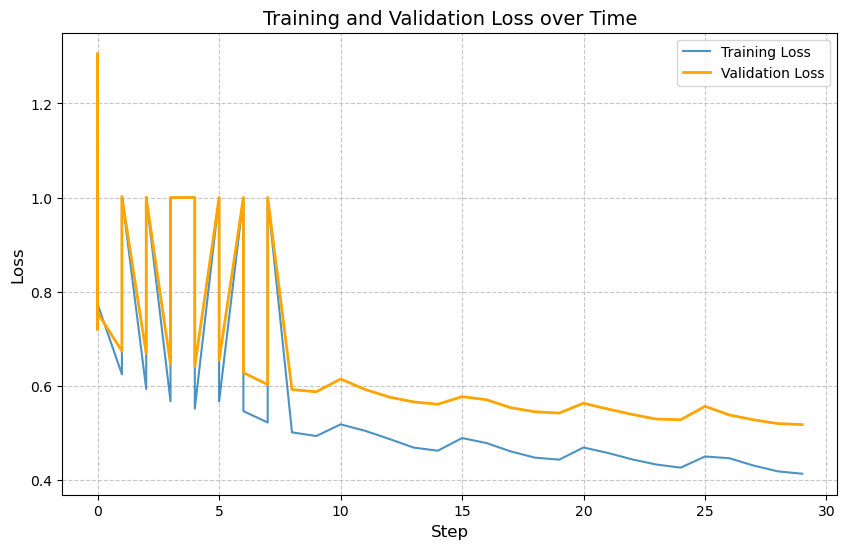

In [ ]:
if 'Loss/Train' in metrics_df.columns and 'Loss/Validation' in metrics_df.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(metrics_df['step'], metrics_df['Loss/Train'], label='Training Loss', alpha=0.8)
    
    
    val_df = metrics_df.dropna(subset=['Loss/Validation'])
    plt.plot(val_df['step'], val_df['Loss/Validation'], label='Validation Loss', color='orange', linewidth=2)
    
    plt.title('Training and Validation Loss over Time', fontsize=14)
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Loss data not found in logs.")

### Plot Validation Metrics (IoU & F1 Score)

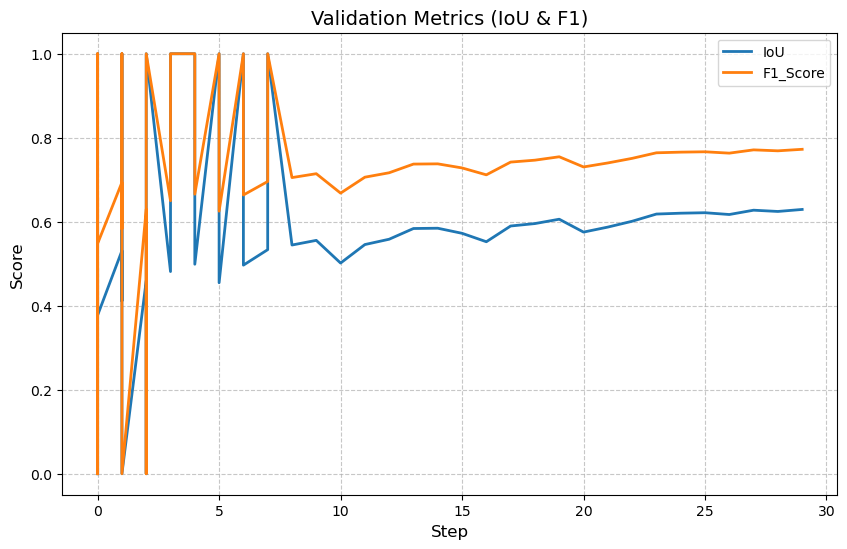

In [58]:
metrics_to_plot = ['Metrics/IoU', 'Metrics/F1_Score']
available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

if available_metrics:
    plt.figure(figsize=(10, 6))
    for metric in available_metrics:
        m_df = metrics_df.dropna(subset=[metric])
        plt.plot(m_df['step'], m_df[metric], label=metric.split('/')[-1], linewidth=2)
        
    plt.title('Validation Metrics (IoU & F1)', fontsize=14)
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Validation metrics not found in logs.")

In [59]:
# Configuration
nc_file_path = os.path.expanduser('~/Downloads/DustSCAN_2022.nc')
model_path = '../outputs/models/best_dustscan_model.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

# Load Model
model = build_advanced_unet_model().to(device)
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("Loaded model weights successfully!")
else:
    print(f"Model checkpoint not found at {model_path}")

Using device: cuda
Loaded model weights successfully!


In [60]:
# Figure out which timesteps belong to UNSEEN months
with xr.open_dataset(nc_file_path, engine='netcdf4') as ds:
    times = ds['time'].values
    plume_data = ds['plume_id'].values
    
times_pd = pd.to_datetime(times)

# Training used: [3, 4, 5, 6, 7, 8]
unseen_months = [1, 2, 9, 10, 11, 12]
unseen_indices = [i for i, t in enumerate(times_pd) if t.month in unseen_months]

# Filter for timesteps in unseen months that have a LOT of dust (> 1000 pixels) so we can see interesting storms
dust_pixels_per_time = (plume_data > 0).sum(axis=(1, 2))
dusty_unseen_indices = [i for i in unseen_indices if dust_pixels_per_time[i] > 1000]

print(f"Found {len(unseen_indices)} timesteps from strictly unseen months (Jan, Feb, Sep, Oct, Nov, Dec).")
print(f"Found {len(dusty_unseen_indices)} timesteps from unseen months that contain large dust storms.")

Found 4318 timesteps from strictly unseen months (Jan, Feb, Sep, Oct, Nov, Dec).
Found 211 timesteps from unseen months that contain large dust storms.


Running full image inference for Timestep 7918...


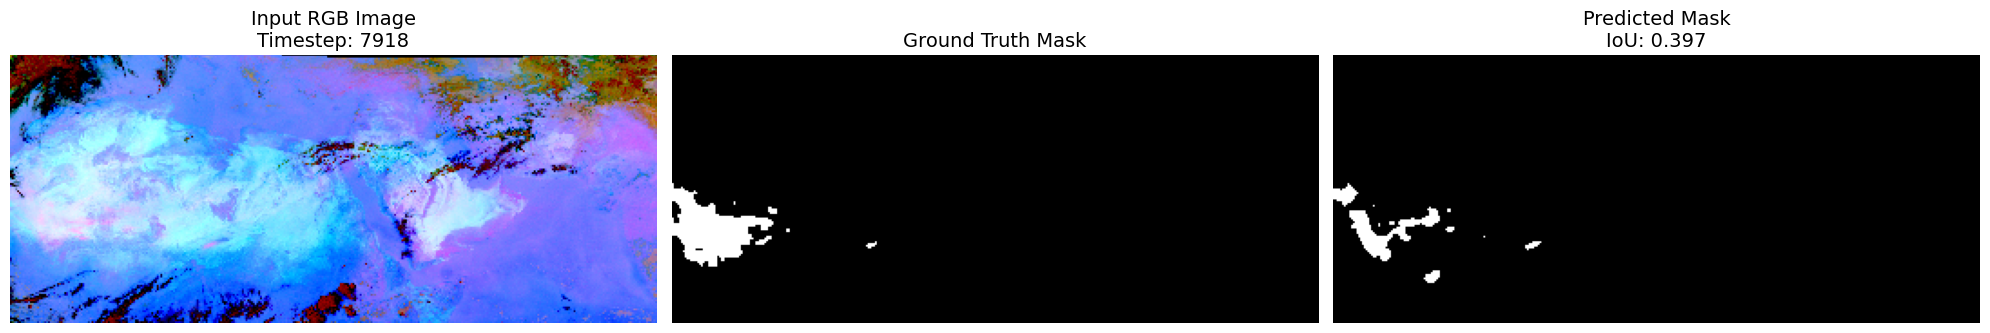

Running full image inference for Timestep 1388...


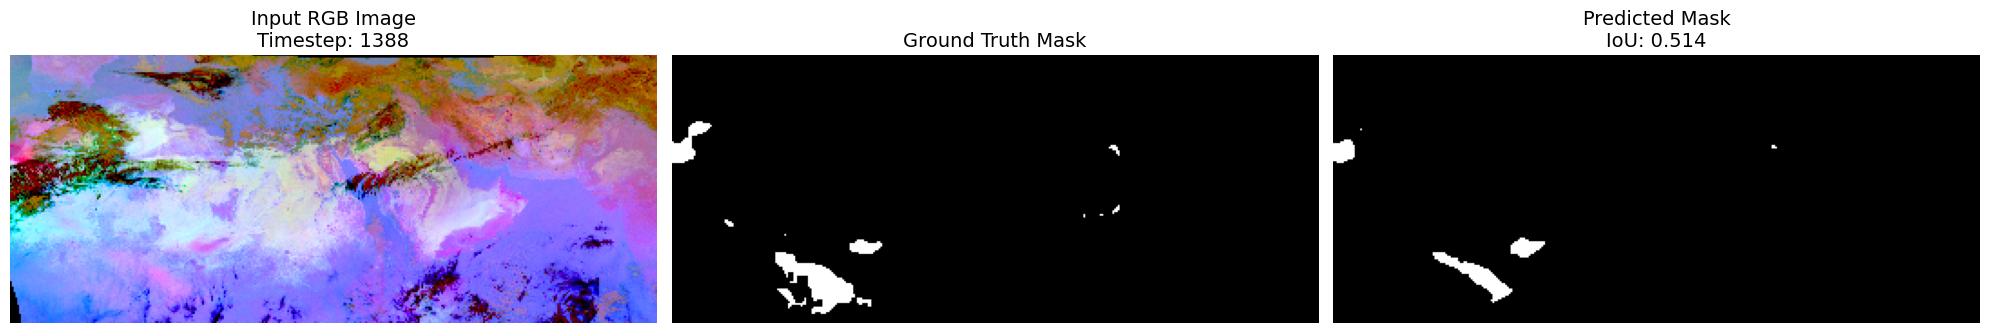

Running full image inference for Timestep 7335...


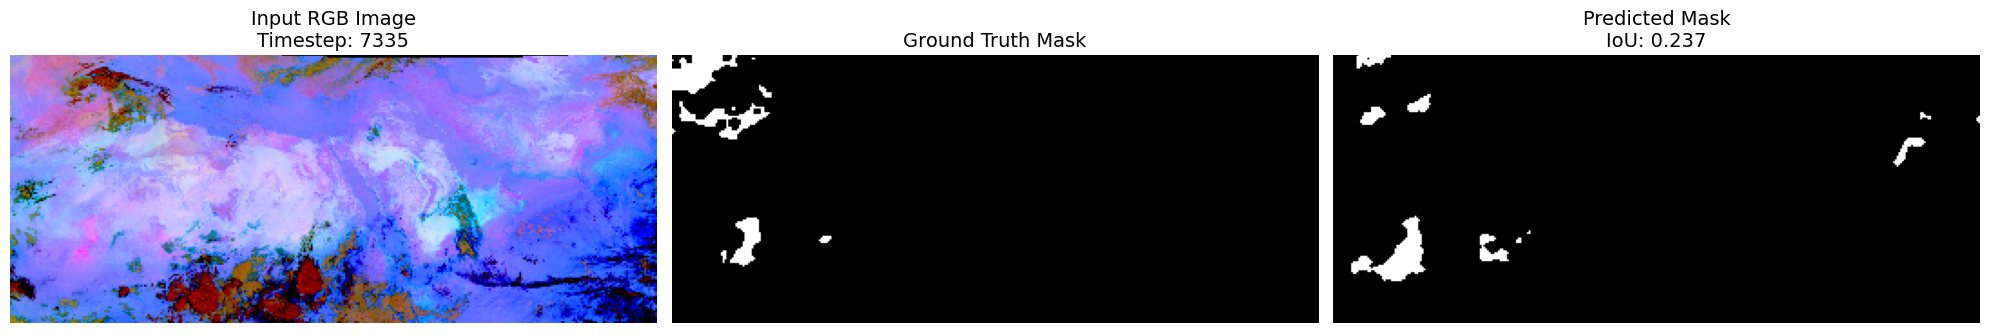

Running full image inference for Timestep 1912...


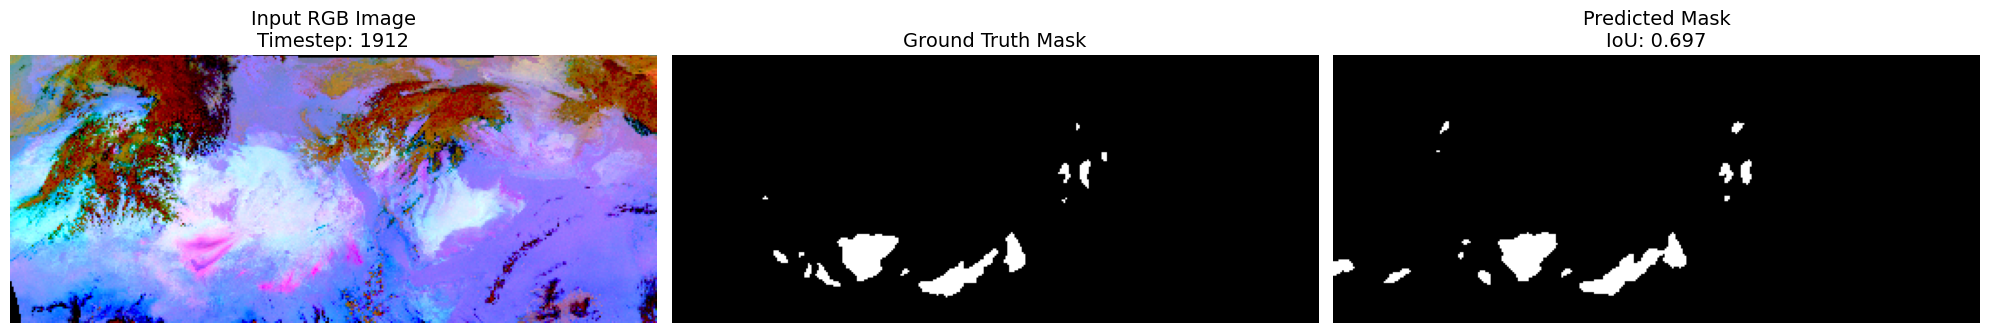

Running full image inference for Timestep 1962...


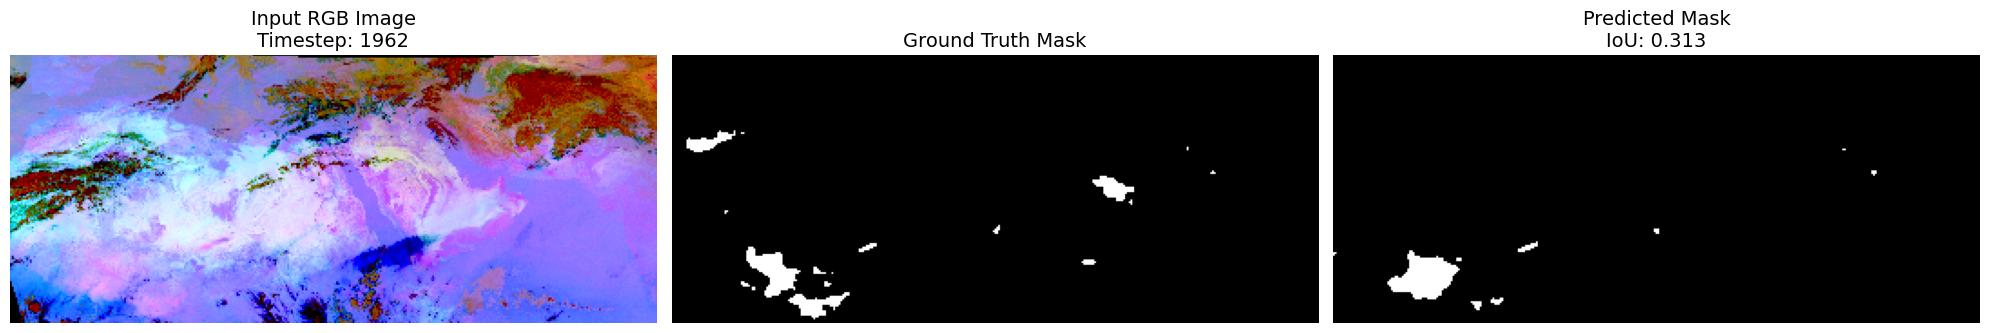

Running full image inference for Timestep 1601...


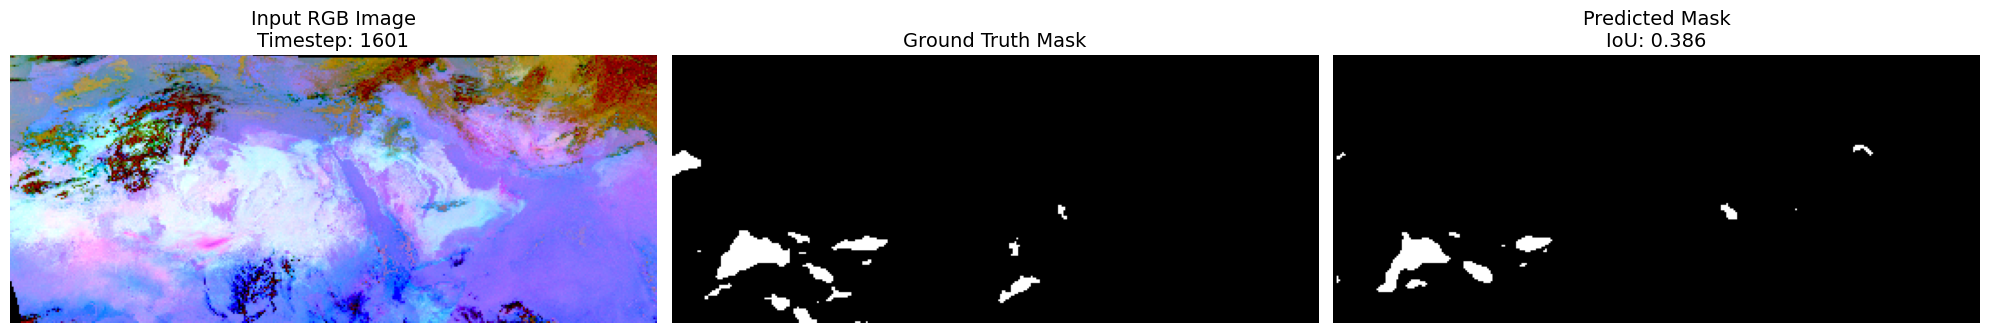

In [61]:
def run_full_image_inference(nc_file_path, time_idx, model, device):
    print(f"Running full image inference for Timestep {time_idx}...")
    with xr.open_dataset(nc_file_path, engine='netcdf4') as ds:
        ds_slice = ds.isel(time=time_idx)
        dust_rgb = ds_slice['dust_rgb'].values
        if dust_rgb.ndim == 3 and dust_rgb.shape[-1] == 3:
            dust_rgb = dust_rgb.transpose(2, 0, 1)
        sun_zenith = ds_slice['sun_zenith'].values
        pdi = ds_slice['pdi'].values
        plume_id = ds_slice['plume_id'].values
        
    # Normalize inputs
    dust_rgb_norm = (dust_rgb.astype(np.float32) - IMAGENET_MEAN) / IMAGENET_STD
    sun_zenith_norm = (sun_zenith - GLOBAL_STATS['sun_zenith_mean']) / (GLOBAL_STATS['sun_zenith_std'] + 1e-8)
    pdi_norm = (pdi - GLOBAL_STATS['pdi_mean']) / (GLOBAL_STATS['pdi_std'] + 1e-8)
    
    X = np.concatenate([
        dust_rgb_norm,
        np.expand_dims(sun_zenith_norm, axis=0),
        np.expand_dims(pdi_norm, axis=0)
    ], axis=0).astype(np.float32)
    
    Y = (plume_id > 0).astype(np.float32)
    X_tensor = torch.nan_to_num(torch.from_numpy(X)).unsqueeze(0).to(device)
    
    # Pad to multiple of 32 (UNet requirement)
    _, _, h, w = X_tensor.shape
    pad_h = (32 - h % 32) % 32
    pad_w = (32 - w % 32) % 32
    
    if pad_h > 0 or pad_w > 0:
        X_tensor = F.pad(X_tensor, (0, pad_w, 0, pad_h), mode='reflect')
        
    # Inference
    with torch.no_grad():
        with torch.autocast('cuda' if torch.cuda.is_available() else 'cpu', enabled=torch.cuda.is_available()):
            outputs = model(X_tensor)
            preds_bin = (torch.sigmoid(outputs) > 0.5).float()
            
    # Remove padding for display
    if pad_h > 0 or pad_w > 0:
        preds_bin = preds_bin[:, :, :h, :w]
        
    pred_np = preds_bin[0, 0].cpu().numpy()
    
    # Calculate IoU for the full image
    intersection = np.logical_and(Y, pred_np).sum()
    union = np.logical_or(Y, pred_np).sum()
    iou = intersection / (union + 1e-6)
    
    # Display
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    display_rgb = np.clip(dust_rgb.transpose(1, 2, 0), 0, 1)
    
    axes[0].imshow(display_rgb)
    axes[0].set_title(f'Input RGB Image\nTimestep: {time_idx}', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(Y, vmin=0, vmax=1, cmap="gray")
    axes[1].set_title('Ground Truth Mask', fontsize=14)
    axes[1].axis('off')
    
    axes[2].imshow(pred_np, vmin=0, vmax=1, cmap="gray")
    axes[2].set_title(f'Predicted Mask\nIoU: {iou:.3f}', fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Pick random full images that have dust
num_samples = 6
selected = np.random.choice(dusty_unseen_indices, min(num_samples, len(dusty_unseen_indices)), replace=False)
for t_idx in selected:
    run_full_image_inference(nc_file_path, t_idx, model, device)
